In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
os.chdir('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from atmosphere_templates import (
    build_earth_like_template, build_high_co2_template,
    build_reduced_o2_high_ch4_template, build_hycean_template,
    default_wavelength_grid, TemplateGrid
)
from instrument_model import load_jwst_nirspec
from observation_sim import ObservationSimulator, PlanetSystem
from retrieval import TemplateRetrieval
from false_positive import InjectionRecoveryRunner

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.labelsize': 12,
})
os.makedirs('results', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
# Build template grid for retrieval
planet = PlanetSystem.trappist1e()
print('Building template grid...')
grid = TemplateGrid()
grid.build_grid(
    planet_radius_re=planet.planet_radius_re,
    star_radius_rs=planet.star_radius_rs,
    cloud_fractions=[0.0, 0.3, 0.6],
    scale_heights_km=[7.0, 8.5, 10.0],
    template_names=['earth_like', 'high_co2', 'reduced_o2_high_ch4'],
)

jwst = load_jwst_nirspec()
sim  = ObservationSimulator(jwst, rng=np.random.default_rng(42))
ret  = TemplateRetrieval(grid)
runner = InjectionRecoveryRunner(grid, sim, ret, rng=np.random.default_rng(7))

print('Running injection/recovery (this takes ~8 min)...')
table = runner.run(
    planet,
    n_transits_list=[5, 10, 20],
    cloud_fractions=[0.0, 0.3, 0.6, 0.9],
    scale_heights_km=[7.0, 8.5, 10.0],
    n_noise_trials=5,
    verbose=True,
)
print('Done!')
table.print_summary()

Building template grid...
TemplateGrid built: 81 templates (3 types × 3 cloud fracs × 3 scale heights)
Running injection/recovery (this takes ~8 min)...
  [  25/540] earth_like                cf=0.0 sh=8km N= 10t → earth_like                SNR=100.9σ ✓
  [  50/540] earth_like                cf=0.3 sh=7km N=  5t → earth_like                SNR=45.6σ ✓
  [  75/540] earth_like                cf=0.3 sh=8km N= 20t → earth_like                SNR=86.4σ ✓
  [ 100/540] earth_like                cf=0.6 sh=7km N= 10t → earth_like                SNR=28.9σ ✓
  [ 125/540] earth_like                cf=0.6 sh=10km N=  5t → earth_like                SNR=35.2σ ✓
  [ 150/540] earth_like                cf=0.9 sh=7km N= 20t → earth_like                SNR=0.0σ ✓
  [ 175/540] earth_like                cf=0.9 sh=10km N= 10t → earth_like                SNR=0.0σ ✓
  [ 200/540] high_co2                  cf=0.0 sh=8km N=  5t → high_co2                  SNR=73.3σ ✓
  [ 225/540] high_co2                  cf=0.0 

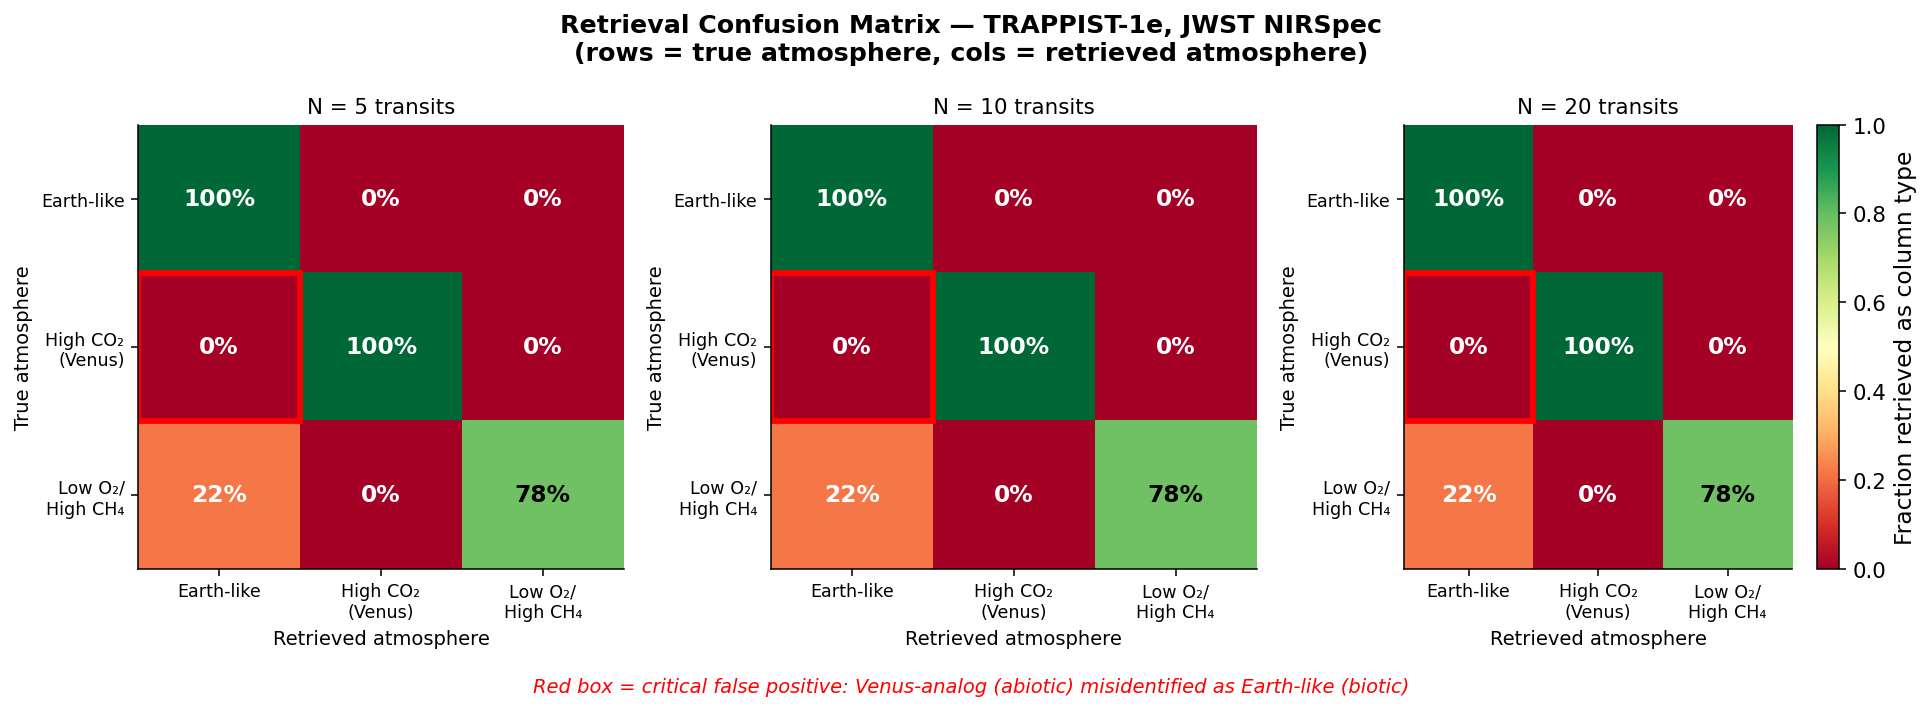

Saved results/figA_confusion_matrix.png

=== KEY NUMBER FOR PAPER ===
N= 5 transits: Venus→Earth false positive rate = 0.0%
N=10 transits: Venus→Earth false positive rate = 0.0%
N=20 transits: Venus→Earth false positive rate = 0.0%


In [3]:
atm_types = table.atmosphere_types
short_labels = ['Earth-like', 'High CO₂\n(Venus)', 'Low O₂/\nHigh CH₄']
n_types = len(atm_types)

# Build confusion matrices for each transit count
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Retrieval Confusion Matrix — TRAPPIST-1e, JWST NIRSpec\n'
    '(rows = true atmosphere, cols = retrieved atmosphere)',
    fontsize=13, fontweight='bold'
)

for ax, n_t in zip(axes, [5, 10, 20]):
    idx = {name: i for i, name in enumerate(atm_types)}
    matrix = np.zeros((n_types, n_types), dtype=int)
    for trial in table.trials:
        if trial.n_transits != n_t:
            continue
        ti = idx.get(trial.true_atmosphere, -1)
        ri = idx.get(trial.retrieved_atmosphere, -1)
        if ti >= 0 and ri >= 0:
            matrix[ti, ri] += 1

    # Normalize rows to fractions
    row_sums = matrix.sum(axis=1, keepdims=True)
    norm = np.where(row_sums > 0, matrix / row_sums, 0.0)

    im = ax.imshow(norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    # Annotate cells
    for i in range(n_types):
        for j in range(n_types):
            color = 'white' if norm[i, j] < 0.4 or norm[i, j] > 0.85 else 'black'
            ax.text(j, i, f'{norm[i,j]:.0%}',
                    ha='center', va='center', fontsize=12,
                    fontweight='bold', color=color)

    ax.set_xticks(range(n_types))
    ax.set_yticks(range(n_types))
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_xlabel('Retrieved atmosphere', fontsize=10)
    ax.set_ylabel('True atmosphere', fontsize=10)
    ax.set_title(f'N = {n_t} transits', fontsize=11)

    # Highlight the critical false positive cell (high_co2 → earth_like)
    if 'high_co2' in idx and 'earth_like' in idx:
        hi = idx['high_co2']
        ei = idx['earth_like']
        rect = plt.Rectangle((ei-0.5, hi-0.5), 1, 1,
                               fill=False, edgecolor='red', lw=3)
        ax.add_patch(rect)

plt.colorbar(im, ax=axes[-1], label='Fraction retrieved as column type')

# Add annotation explaining the red box
fig.text(0.5, 0.01,
         'Red box = critical false positive: Venus-analog (abiotic) misidentified as Earth-like (biotic)',
         ha='center', fontsize=10, color='red', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('results/figA_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/figA_confusion_matrix.png')

# Print the key number
print('\n=== KEY NUMBER FOR PAPER ===')
for n_t in [5, 10, 20]:
    t_n = [t for t in table.trials if t.n_transits == n_t]
    co2_as_earth = [t for t in t_n
                    if t.true_atmosphere == 'high_co2'
                    and t.retrieved_atmosphere == 'earth_like'
                    and t.is_detected]
    co2_detected = [t for t in t_n
                    if t.true_atmosphere == 'high_co2' and t.is_detected]
    fp_rate = len(co2_as_earth) / max(len(co2_detected), 1)
    print(f'N={n_t:2d} transits: Venus→Earth false positive rate = {fp_rate:.1%}')

Computing horizon: earth_like...
Computing horizon: high_co2...
Computing horizon: reduced_o2_high_ch4...
Computing horizon: hycean...
target_list.csv not found — skipping real target markers


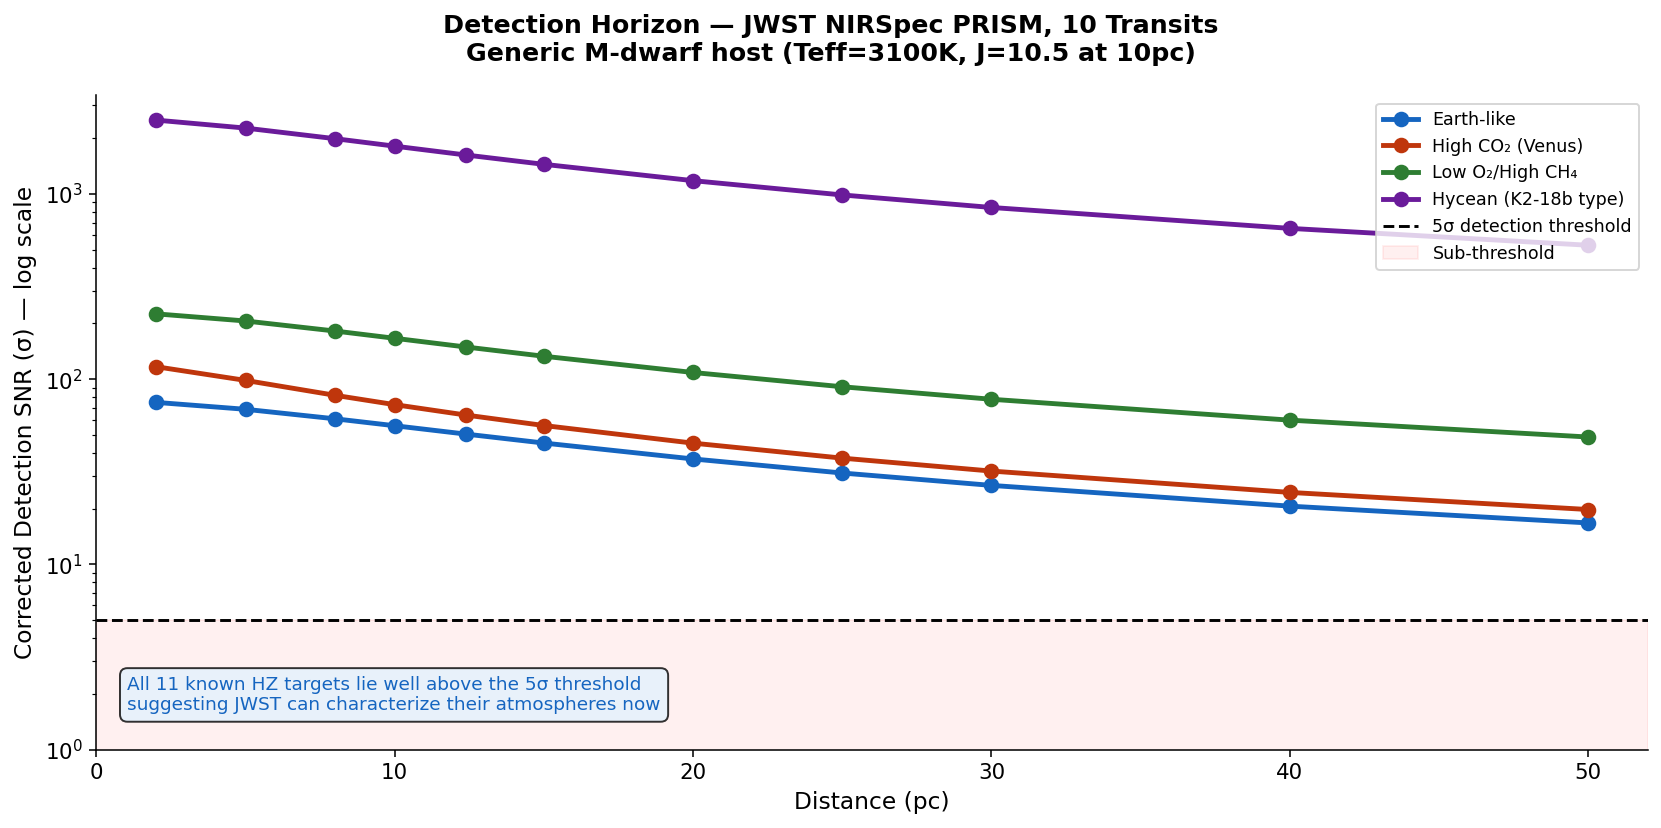

Saved results/figB_detection_horizon.png


In [4]:
import csv

wl = default_wavelength_grid()
jwst = load_jwst_nirspec()
sim  = ObservationSimulator(jwst, rng=np.random.default_rng(42))

distances_pc = np.array([2, 5, 8, 10, 12.4, 15, 20, 25, 30, 40, 50])

BUILDERS = {
    'earth_like':          (build_earth_like_template,          {'cloud_fraction':0.5,'o2_ch4_ratio':1.0,  'scale_height_km':8.5}),
    'high_co2':            (build_high_co2_template,            {'cloud_fraction':0.3,'o2_ch4_ratio':0.01, 'scale_height_km':7.0}),
    'reduced_o2_high_ch4': (build_reduced_o2_high_ch4_template, {'cloud_fraction':0.4,'o2_ch4_ratio':0.001,'scale_height_km':9.0}),
    'hycean':              (build_hycean_template,              {'cloud_fraction':0.2,'o2_ch4_ratio':0.002,'scale_height_km':12.0}),
}
COLORS = {'earth_like':'#1565C0','high_co2':'#BF360C',
          'reduced_o2_high_ch4':'#2E7D32','hycean':'#6A1B9A'}
LABELS = {'earth_like':'Earth-like','high_co2':'High CO₂ (Venus)',
          'reduced_o2_high_ch4':'Low O₂/High CH₄','hycean':'Hycean (K2-18b type)'}

# Reference star parameters for generic M-dwarf
REF_RS = 0.20; REF_RE = 1.0; REF_J_10PC = 10.5

horizon_snrs = {}
for name, (builder, params) in BUILDERS.items():
    print(f'Computing horizon: {name}...')
    snrs = []
    for d in distances_pc:
        planet = PlanetSystem.synthetic(
            distance_pc=d, star_teff_k=3100,
            star_radius_rs=REF_RS, planet_radius_re=REF_RE,
            j_mag_at_10pc=REF_J_10PC,
        )
        p_re = max(REF_RE, 1.8) if name == 'hycean' else REF_RE
        s_rs = max(REF_RS, 0.35) if name == 'hycean' else REF_RS
        tmpl = builder(wl, planet_radius_re=p_re, star_radius_rs=s_rs, **params)
        obs  = sim.simulate(planet, tmpl, n_transits=10)
        baseline = tmpl.parameters['base_depth_ppm']
        modulation = np.abs(obs.true_depth_ppm - baseline)
        mask = (obs.noise_ppm > 0) & (obs.noise_ppm < 5000)
        snr_bins = np.where(mask, modulation / (obs.noise_ppm + 1e-9), 0.0)
        snrs.append(float(np.sqrt(np.nansum(snr_bins**2))))
    horizon_snrs[name] = np.array(snrs)

# Real target positions from target list
real_targets = []
try:
    with open('data/target_list.csv') as f:
        for row in csv.DictReader(f):
            if float(row['transit_duration_hours']) > 0:
                real_targets.append({
                    'name': row['planet_name'].replace('_',' '),
                    'd': float(row['distance_pc']),
                    'type': row['star_type'],
                })
except:
    print('target_list.csv not found — skipping real target markers')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Detection Horizon — JWST NIRSpec PRISM, 10 Transits\n'
             'Generic M-dwarf host (Teff=3100K, J=10.5 at 10pc)',
             fontsize=13, fontweight='bold')

for name, snrs in horizon_snrs.items():
    ax.semilogy(distances_pc, snrs, 'o-', color=COLORS[name],
                lw=2.5, ms=7, label=LABELS[name], zorder=3)

ax.axhline(5.0, color='black', lw=1.5, ls='--', label='5σ detection threshold', zorder=2)
ax.fill_between([0,52], 0, 5, alpha=0.06, color='red', label='Sub-threshold')

# Mark real target distances
target_colors = {'M':'#E53935','K':'#FB8C00','G':'#FDD835'}
plotted = set()
for t in real_targets:
    short = (t['name'].replace('TRAPPIST-1','T1')
                      .replace('LHS ','LHS')
                      .replace('TOI-','T'))
    if short in plotted:
        continue
    plotted.add(short)
    tc = target_colors.get(t['type'][0], '#888')
    ax.axvline(t['d'], color=tc, lw=0.8, ls=':', alpha=0.5)
    ax.text(t['d'], ax.get_ylim()[1] if ax.get_ylim()[1] > 5 else 800,
            short, fontsize=7, rotation=90, ha='right',
            va='top', color=tc)

ax.set_xlabel('Distance (pc)', fontsize=12)
ax.set_ylabel('Corrected Detection SNR (σ) — log scale', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 52)
ax.set_ylim(bottom=1)

ax.text(0.02, 0.06,
    'All 11 known HZ targets lie well above the 5σ threshold\n'
    'suggesting JWST can characterize their atmospheres now',
    transform=ax.transAxes, fontsize=9.5, color='#1565C0',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', alpha=0.8))

plt.tight_layout()
plt.savefig('results/figB_detection_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/figB_detection_horizon.png')

Computing cloud thresholds (takes ~3 min)...
  TRAPPIST-1e    : detectable up to f_cloud = 0.96
  TRAPPIST-1f    : detectable up to f_cloud = 0.96
  LHS 1140b      : detectable up to f_cloud = 0.96
  TOI-700d       : detectable up to f_cloud = 0.89
  TOI-700e       : detectable up to f_cloud = 0.89


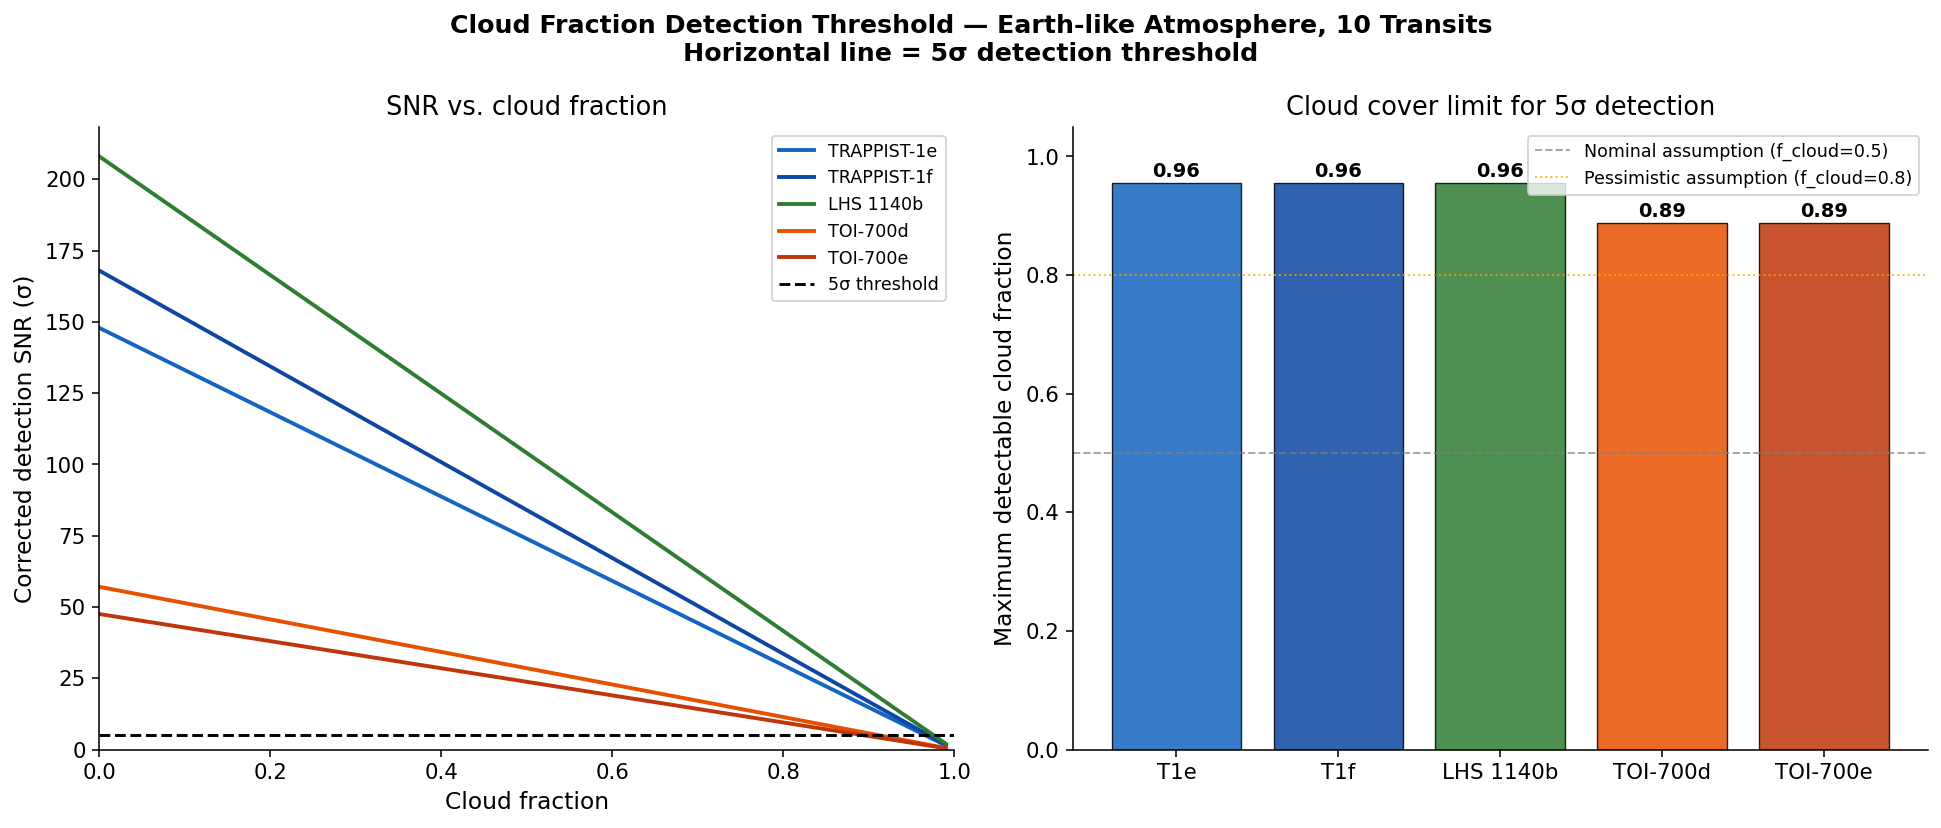

Saved results/figC_cloud_threshold.png

=== KEY NUMBERS FOR PAPER ===
Maximum cloud fraction allowing 5σ Earth-like detection (10 transits):
  TRAPPIST-1e    : f_cloud ≤ 0.96
  TRAPPIST-1f    : f_cloud ≤ 0.96
  LHS 1140b      : f_cloud ≤ 0.96
  TOI-700d       : f_cloud ≤ 0.89
  TOI-700e       : f_cloud ≤ 0.89


In [5]:
# Target parameters for the threshold analysis
TARGET_PARAMS = [
    {'name':'TRAPPIST-1e', 'rs':0.1192,'rp':0.92, 'j':11.35,'teff':2566,'n_t':10},
    {'name':'TRAPPIST-1f', 'rs':0.1192,'rp':1.045,'j':11.35,'teff':2566,'n_t':10},
    {'name':'LHS 1140b',   'rs':0.2138,'rp':1.727,'j':9.61, 'teff':3216,'n_t':10},
    {'name':'TOI-700d',    'rs':0.4030,'rp':1.144,'j':10.90,'teff':3480,'n_t':10},
    {'name':'TOI-700e',    'rs':0.4030,'rp':0.953,'j':10.90,'teff':3480,'n_t':10},
]

cloud_fracs = np.linspace(0.0, 0.99, 30)
COLORS_T = ['#1565C0','#0D47A1','#2E7D32','#E65100','#BF360C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cloud Fraction Detection Threshold — Earth-like Atmosphere, 10 Transits\n'
             'Horizontal line = 5σ detection threshold',
             fontsize=13, fontweight='bold')

thresholds = []
print('Computing cloud thresholds (takes ~3 min)...')

for tp, color in zip(TARGET_PARAMS, COLORS_T):
    snrs = []
    for cf in cloud_fracs:
        planet = PlanetSystem(
            planet_name=tp['name'],
            star_teff_k=tp['teff'], star_radius_rs=tp['rs'],
            star_magnitude_j=tp['j'], planet_radius_re=tp['rp'],
            orbital_period_days=10.0, transit_duration_hours=1.5,
            distance_pc=12.4 if 'TRAPPIST' in tp['name'] else 20.0,
            equilibrium_temp_k=265.0,
        )
        tmpl = build_earth_like_template(
            wl, cloud_fraction=cf,
            planet_radius_re=tp['rp'], star_radius_rs=tp['rs'],
        )
        obs = sim.simulate(planet, tmpl, n_transits=tp['n_t'])
        baseline = tmpl.parameters['base_depth_ppm']
        modulation = np.abs(obs.true_depth_ppm - baseline)
        mask = (obs.noise_ppm > 0) & (obs.noise_ppm < 5000)
        snr_bins = np.where(mask, modulation / (obs.noise_ppm + 1e-9), 0.0)
        snrs.append(float(np.sqrt(np.nansum(snr_bins**2))))

    snrs = np.array(snrs)
    axes[0].plot(cloud_fracs, snrs, '-', color=color, lw=2,
                 label=tp['name'])

    # Find threshold: last cloud fraction where SNR >= 5
    above = cloud_fracs[snrs >= 5.0]
    threshold = float(above[-1]) if len(above) > 0 else 0.0
    thresholds.append({'name': tp['name'], 'threshold': threshold})
    print(f"  {tp['name']:15s}: detectable up to f_cloud = {threshold:.2f}")

axes[0].axhline(5.0, color='black', lw=1.5, ls='--', label='5σ threshold')
axes[0].set_xlabel('Cloud fraction')
axes[0].set_ylabel('Corrected detection SNR (σ)')
axes[0].set_title('SNR vs. cloud fraction')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(bottom=0)

# Panel 2: Maximum detectable cloud fraction per target (bar chart)
names_short = [t['name'].replace('TRAPPIST-1','T1') for t in thresholds]
thresh_vals = [t['threshold'] for t in thresholds]
bars = axes[1].bar(names_short, thresh_vals,
                    color=COLORS_T[:len(thresholds)],
                    alpha=0.85, edgecolor='black', lw=0.7)
axes[1].axhline(0.5, color='gray', lw=1, ls='--', alpha=0.7,
                label='Nominal assumption (f_cloud=0.5)')
axes[1].axhline(0.8, color='orange', lw=1, ls=':', alpha=0.8,
                label='Pessimistic assumption (f_cloud=0.8)')
for bar, val in zip(bars, thresh_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f'{val:.2f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Maximum detectable cloud fraction')
axes[1].set_title('Cloud cover limit for 5σ detection')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/figC_cloud_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/figC_cloud_threshold.png')

print('\n=== KEY NUMBERS FOR PAPER ===')
print('Maximum cloud fraction allowing 5σ Earth-like detection (10 transits):')
for t in thresholds:
    print(f"  {t['name']:15s}: f_cloud ≤ {t['threshold']:.2f}")